In [10]:
# ----------------------------------------------------------------------
# [과제]
# ----------------------------------------------------------------------
# CartPole-v1 환경에서 A3C·A2C·ACER 세 가지 Actor-Critic 계열 강화학습 알고리즘을 구현하고 성능을 비교한다.
# ACER는 Experience Replay와 Importance Sampling을 결합하여 기존 on-policy 방식의 샘플 비효율 문제를 개선한 알고리즘이다.
# 각 알고리즘의 설계 원리와 하이퍼파라미터가 학습 안정성 및 수렴 성능에 미치는 영향을 실험적으로 분석하는 것을 목표로 한다.

In [11]:
# ==========================================
# 0. 라이브러리 임포트 및 환경 설정
# ==========================================

import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import collections
import random
import os
import csv
from tqdm.auto import tqdm


# GPU(CUDA) 활용 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:

# ==========================================
# 1. 환경 설정 및 하이퍼파라미터
# ==========================================
# CartPole-v1 : 막대를 쓰러뜨리지 않고 오래 버틸수록 높은 점수 (최대 500)
# gamma       : 미래 보상 할인율 — 1에 가까울수록 장기 보상을 더 중시
# max_train_ep: 총 학습 에피소드 수 (1000으로 충분한 수렴 여유 확보)
gamma        = 0.99
max_train_ep = 1000

os.makedirs("Results", exist_ok=True)   # 결과 저장 폴더 자동 생성

# ── A3C (Asynchronous Advantage Actor-Critic) ─────────────────────
# Monte Carlo return + GAE(λ=0.96) 방식으로 advantage 추정
# 분산(variance)과 편향(bias) 사이의 균형: λ 높을수록 분산 증가
A3C_LR      = 0.0003   # Adam 옵티마이저 학습률
A3C_ENTROPY = 0.05     # 엔트로피 보너스 계수: 탐색(exploration) 촉진

# ── A2C (Advantage Actor-Critic, single-thread) ───────────────────
# n-step TD로 return 추정 → MC보다 낮은 분산, 더 잦은 업데이트
# CosineAnnealingWarmRestarts: 주기마다 LR을 리셋하여 후반 학습 붕괴 방지
A2C_LR      = 0.0003
A2C_N_STEPS = 10       # [개선] 5→10: n-step이 클수록 variance 감소
A2C_ENTROPY = 0.10     # [개선] 0.05→0.10: 후반 탐색력 유지 (catastrophic forgetting 억제)

# ── ACER (Actor-Critic with Experience Replay) ────────────────────
# Off-policy 리플레이 버퍼 + importance sampling으로 샘플 효율 향상
ACER_LR           = 0.0003
ACER_BATCH        = 16       # [개선] 32→16: 버퍼가 적을 때도 빠른 업데이트
ACER_BUF_MAX      = 50000    # 리플레이 버퍼 최대 크기
ACER_MIN_BUF      = 200      # [개선] 1000→200: 초반 학습 지연 해소
ACER_C_CLIP       = 2.0      # [개선] 3.0→2.0: importance ratio 클리핑으로 안정성 향상
ACER_ENTROPY      = 0.05     # 기본 엔트로피 계수 (annealing으로 동적 조정)
ACER_TAU          = 0.01     # [개선] 0.005→0.01: 타겟 네트워크 소프트 업데이트 속도
ACER_TRAIN_PER_EP = 8        # 에피소드당 최대 학습 횟수 (버퍼 상태에 따라 동적 축소)


# ==========================================
# 2. 리플레이 버퍼 (ACER 전용)
# ==========================================
# FIFO(선입선출) deque로 구현: 오래된 경험을 자동으로 삭제
# 저장 내용: 상태(s), 행동(a), 보상(r), 다음상태(s'), 행동확률분포, 종료여부
class ReplayBuffer:
    def __init__(self, maxlen=ACER_BUF_MAX):
        self.buf = collections.deque(maxlen=maxlen)

    def put(self, s, a, r, s_prime, prob_dist, terminated):
        """경험 한 스텝을 버퍼에 저장. prob_dist는 ACER의 importance ratio 계산에 사용."""
        self.buf.append((s, a, r, s_prime, prob_dist, terminated))

    def sample(self, n):
        """무작위 미니배치 n개 추출 → 각 필드를 텐서로 변환하여 반환."""
        batch    = random.sample(self.buf, n)
        s_arr    = np.array([b[0] for b in batch], dtype=np.float32)
        a_arr    = [[b[1]] for b in batch]
        r_arr    = [[b[2]] for b in batch]
        sp_arr   = np.array([b[3] for b in batch], dtype=np.float32)
        prob_arr = np.array([b[4] for b in batch], dtype=np.float32)
        # terminated=True이면 done_mask=0 → 종료 이후 미래 가치 차단
        done_arr = [[0.0 if b[5] else 1.0] for b in batch]
        return (
            torch.tensor(s_arr).to(device),
            torch.tensor(a_arr).to(device),
            torch.tensor(r_arr).to(device),
            torch.tensor(sp_arr).to(device),
            torch.tensor(prob_arr).to(device),
            torch.tensor(done_arr).to(device),
        )

    def size(self):
        return len(self.buf)


# ==========================================
# 3. 신경망 모델
# ==========================================

class ACNet(nn.Module):
    """
    A3C / A2C 공용 Actor-Critic 네트워크.
    - shared  : 공유 특징 추출 레이어 (backbone)
    - pi_head : 정책 헤드 → 소프트맥스로 행동 확률분포 π(a|s) 출력
    - v_head  : 가치 헤드 → 스칼라 상태 가치 V(s) 출력
    두 헤드가 동일한 backbone을 공유하므로 파라미터 효율적.
    """
    def __init__(self, state_dim=4, action_dim=2, hidden=128):
        super().__init__()
        self.shared  = nn.Sequential(nn.Linear(state_dim, hidden), nn.ReLU())
        self.pi_head = nn.Linear(hidden, action_dim)
        self.v_head  = nn.Linear(hidden, 1)

    def pi(self, x):
        """정책 확률분포 π(a|s) 반환."""
        return F.softmax(self.pi_head(self.shared(x)), dim=-1)

    def v(self, x):
        """상태 가치 V(s) 반환."""
        return self.v_head(self.shared(x))

    def pi_v(self, x):
        """π(a|s)와 V(s)를 한 번의 forward pass로 동시 계산 (효율성)."""
        h = self.shared(x)
        return F.softmax(self.pi_head(h), dim=-1), self.v_head(h)


class ACERNet(nn.Module):
    """
    ACER 전용 Actor-Critic 네트워크.
    - pi_head : 정책 헤드 → π(a|s)
    - q_head  : Q-함수 헤드 → Q(s,a) (모든 행동에 대한 Q값 동시 출력)
    A2C의 V(s) 대신 Q(s,a)를 사용하여 off-policy 중요도 가중치 계산 가능.
    """
    def __init__(self, state_dim=4, action_dim=2, hidden=128):
        super().__init__()
        self.shared  = nn.Sequential(nn.Linear(state_dim, hidden), nn.ReLU())
        self.pi_head = nn.Linear(hidden, action_dim)
        self.q_head  = nn.Linear(hidden, action_dim)

    def pi(self, x):
        return F.softmax(self.pi_head(self.shared(x)), dim=-1)

    def q(self, x):
        """모든 행동에 대한 Q(s,a) 벡터 반환."""
        return self.q_head(self.shared(x))


# ==========================================
# 4. A3C 학습 함수 — Monte Carlo Return + GAE
# ==========================================
def train_a3c(model, optimizer, trajectory):
    """
    한 에피소드 전체 궤적(trajectory)으로 A3C 업데이트.

    GAE (Generalized Advantage Estimation):
        δ_t = r_t + γ·V(s_{t+1}) - V(s_t)          ← TD 오차
        A_t = δ_t + (γλ)·δ_{t+1} + (γλ)²·δ_{t+2}  ← 지수 가중 합산
    λ=0.96: 분산(variance)과 편향(bias) 사이의 균형점
    Advantage 정규화: 에피소드 길이 차이로 인한 스케일 불균형 제거
    """
    # 궤적에서 상태·행동·보상·종료 분리
    states  = torch.tensor(np.array([t[0] for t in trajectory]), dtype=torch.float32).to(device)
    actions = torch.tensor([t[1] for t in trajectory]).to(device)
    rewards = [t[2] for t in trajectory]
    terms   = [t[4] for t in trajectory]

    # 현재 정책의 확률분포와 상태 가치 한 번에 계산
    probs, values = model.pi_v(states)

    # 에피소드가 중간에 끊겼다면(time-out) 마지막 상태의 부트스트랩 가치 사용
    G = 0.0
    if not terms[-1]:
        s_last = torch.tensor(trajectory[-1][3], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            G = model.v(s_last).item()

    # ── GAE 역방향 계산 (뒤에서 앞으로) ─────────────────────────────
    lambda_gae = 0.96   # [개선] 0.98→0.96: 분산 과대 억제
    gae        = 0.0
    gaes       = []
    values_np  = values.detach().cpu().numpy().flatten()
    v_next     = G

    for i in reversed(range(len(rewards))):
        mask   = 0.0 if terms[i] else 1.0          # 종료 시 미래 차단
        delta  = rewards[i] + gamma * v_next * mask - values_np[i]
        gae    = delta + gamma * lambda_gae * mask * gae
        gaes.insert(0, gae)
        v_next = values_np[i]

    gaes = torch.tensor(gaes, dtype=torch.float32).unsqueeze(1).to(device)

    # ── Advantage 정규화 (에피소드 길이 스케일 불균형 제거) ──────────
    if gaes.shape[0] > 1:
        gaes = (gaes - gaes.mean()) / (gaes.std() + 1e-8)

    # 정규화된 advantage로 return 재구성 (타겟 가치)
    returns = (gaes + values.detach()).detach()

    # ── 손실 함수 계산 ───────────────────────────────────────────────
    log_probs  = torch.log(probs + 1e-8)
    log_prob_a = log_probs.gather(1, actions.unsqueeze(1))   # 선택한 행동의 로그확률
    entropy    = -(probs * log_probs).sum(dim=1).mean()       # 정책 엔트로피

    # 정책 손실: -log π(a|s)·A (최대화 → 음수로 최소화)
    # 엔트로피 보너스: 탐색 촉진 (-)
    pi_loss = -(log_prob_a * gaes).mean() - A3C_ENTROPY * entropy
    v_loss  = F.smooth_l1_loss(values, returns)   # Huber 손실로 V(s) 학습

    optimizer.zero_grad()
    (pi_loss + v_loss).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # 그래디언트 클리핑
    optimizer.step()


# ==========================================
# 5. A2C 학습 함수 — n-step TD Return
# ==========================================
def train_a2c(model, optimizer, chunk, next_s, next_term):
    """
    n-step 청크(chunk)로 A2C 업데이트.

    n-step Return:
        G_t = r_t + γ·r_{t+1} + ... + γⁿ·V(s_{t+n})
    n=10: 5보다 분산이 낮고 에피소드 전체(MC)보다 편향이 낮음.
    """
    states  = torch.tensor(np.array([t[0] for t in chunk]), dtype=torch.float32).to(device)
    actions = torch.tensor([t[1] for t in chunk]).to(device)
    rewards = [t[2] for t in chunk]
    terms   = [t[4] for t in chunk]

    # 청크 끝이 에피소드 종료가 아니면 다음 상태 가치로 부트스트랩
    G = 0.0
    if not next_term:
        s_next = torch.tensor(next_s, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            G = model.v(s_next).item()

    # ── n-step return 역방향 계산 ────────────────────────────────────
    returns = []
    for r, term in zip(reversed(rewards), reversed(terms)):
        G = r + gamma * G * (0.0 if term else 1.0)
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32).unsqueeze(1).to(device)

    # ── 손실 계산 ────────────────────────────────────────────────────
    probs, values = model.pi_v(states)
    log_probs     = torch.log(probs + 1e-8)
    log_prob_a    = log_probs.gather(1, actions.unsqueeze(1))
    advantage     = (returns - values).detach()   # 그래디언트 차단 (정책만 업데이트)
    entropy       = -(probs * log_probs).sum(dim=1).mean()

    # [개선] entropy=0.10: LR이 작아져도 정책 다양성 유지 (후반 붕괴 억제)
    pi_loss = -(log_prob_a * advantage).mean() - A2C_ENTROPY * entropy
    v_loss  = F.smooth_l1_loss(values, returns.detach())

    optimizer.zero_grad()
    (pi_loss + v_loss).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()


# ==========================================
# 6. ACER 학습 함수 — Off-policy + Importance Sampling
# ==========================================
def train_acer(model, target_model, optimizer, memory, entropy_coef):
    """
    리플레이 버퍼에서 샘플링하여 ACER 업데이트.

    핵심 메커니즘:
    1. Importance Ratio ρ = π_now(a|s) / π_old(a|s) — 현재/과거 정책 비율
    2. c-bar = min(ρ, C_CLIP=2.0) — 비율 클리핑으로 분산 제어
    3. Bias Correction — 클리핑된 부분 보완
    4. 타겟 네트워크 — Q값 추정 안정화 (τ=0.01 소프트 업데이트)
    """
    if memory.size() < ACER_MIN_BUF:
        return   # 최소 버퍼 미달 시 조기 종료

    s, a, r, s_prime, old_prob, done_mask = memory.sample(ACER_BATCH)

    # ── 현재 네트워크: π, Q, V 계산 ─────────────────────────────────
    pi   = model.pi(s)
    q    = model.q(s)
    pi_a = pi.gather(1, a)                              # 선택 행동 확률
    q_a  = q.gather(1, a)                               # 선택 행동 Q값
    v    = (pi * q).sum(dim=1, keepdim=True).detach()  # V(s) = Σ π(a)·Q(s,a)

    # ── Importance Ratio 계산 및 클리핑 ─────────────────────────────
    old_prob_a = old_prob.gather(1, a)
    rho_a      = (pi_a / (old_prob_a + 1e-8)).detach()
    c_bar      = rho_a.clamp(max=ACER_C_CLIP)          # [개선] 2.0으로 낮춰 안정성 향상

    # ── 타겟 네트워크로 TD 타겟 계산 ────────────────────────────────
    with torch.no_grad():
        pi_p   = target_model.pi(s_prime)
        q_p    = target_model.q(s_prime)
        v_p    = (pi_p * q_p).sum(dim=1, keepdim=True)
        td_tgt = r + gamma * v_p * done_mask            # 벨만 타겟

    # ── 메인 정책 손실 (클리핑된 importance ratio 적용) ─────────────
    adv_a        = (q_a - v).detach()
    pi_loss_main = -(c_bar * adv_a * torch.log(pi_a + 1e-8)).mean()

    # ── 바이어스 보정 항 (클리핑으로 누락된 부분 복원) ──────────────
    with torch.no_grad():
        rho_all = (pi / (old_prob + 1e-8)).detach()
        adv_all = (q.detach() - v)
        # (1 - C/ρ)⁺: 클리핑이 발생한 행동에만 보정 가중치 적용
        bc_coef = torch.clamp(1.0 - ACER_C_CLIP / (rho_all + 1e-8), min=0.0)
        bc_w    = bc_coef * pi.detach()

    pi_loss_bc = -(bc_w * adv_all * torch.log(pi + 1e-8)).sum(dim=1).mean()

    # ── 전체 손실 = Q손실 + 정책손실 - 엔트로피 보너스 ─────────────
    entropy = -(pi * torch.log(pi + 1e-8)).sum(dim=1).mean()
    q_loss  = F.smooth_l1_loss(q_a, td_tgt)
    # entropy_coef는 annealing으로 전달 (초반 탐색↑, 후반 안정↑)
    loss    = q_loss + pi_loss_main + pi_loss_bc - entropy_coef * entropy

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()


# ==========================================
# 7. 알고리즘별 실행 함수
# ==========================================

def run_a3c(seed=0):
    """A3C 학습: 에피소드 완료 후 전체 궤적으로 한 번 업데이트."""
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env    = gym.make("CartPole-v1")
    model  = ACNet().to(device)
    opt    = optim.Adam(model.parameters(), lr=A3C_LR)
    scores = []

    for ep in tqdm(range(1, max_train_ep + 1), desc="A3C  "):
        s, _ = env.reset()
        done, traj, score = False, [], 0.0

        # ── 에피소드 수집 ────────────────────────────────────────────
        while not done:
            st = torch.tensor(s, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                prob = model.pi(st)
            a = Categorical(prob).sample().item()
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            traj.append((s, a, r, s2, term))
            s = s2; score += r

        # ── 에피소드 종료 후 GAE 기반 업데이트 ──────────────────────
        train_a3c(model, opt, traj)
        scores.append(score)

    env.close()
    return scores


def run_a2c(seed=0):
    """
    A2C 학습: n-step마다 업데이트 + CosineAnnealingWarmRestarts.

    WarmRestarts(T_0=200, T_mult=2): ep 200·400·800에서 LR 리셋
    → 이전 버전의 후반 성능 붕괴(LR→0) 문제 해결
    """
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env   = gym.make("CartPole-v1")
    model = ACNet().to(device)
    opt   = optim.Adam(model.parameters(), lr=A2C_LR)
    # [개선] CosineAnnealingLR → WarmRestarts: 주기 재가열로 후반 학습 유지
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=200, T_mult=2, eta_min=1e-4
    )
    scores = []

    for ep in tqdm(range(1, max_train_ep + 1), desc="A2C  "):
        s, _ = env.reset()
        done, score, chunk = False, 0.0, []

        while not done:
            st = torch.tensor(s, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                prob = model.pi(st)
            a = Categorical(prob).sample().item()
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            chunk.append((s, a, r, s2, term))
            s = s2; score += r

            # n-step 청크가 가득 차거나 에피소드 종료 시 업데이트
            if len(chunk) >= A2C_N_STEPS or done:
                train_a2c(model, opt, chunk, s2, term)
                chunk = []

        scheduler.step()   # 에피소드마다 LR 스케줄 갱신
        scores.append(score)

    env.close()
    return scores


def run_acer(seed=0):
    """
    ACER 학습: 경험 리플레이 + 타겟 네트워크 + entropy annealing.

    Entropy Annealing: entropy_coef = max(0.01, 0.05×(1 - ep/max×0.5))
    → 초반(ep~0)  : coef≈0.05 → 탐색 넓게
    → 후반(ep~max): coef≈0.025 → 수렴에 집중
    """
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env          = gym.make("CartPole-v1")
    model        = ACERNet().to(device)
    target_model = ACERNet().to(device)
    target_model.load_state_dict(model.state_dict())   # 타겟 = 온라인 복사본으로 초기화
    opt    = optim.Adam(model.parameters(), lr=ACER_LR)
    memory = ReplayBuffer()
    scores = []

    for ep in tqdm(range(1, max_train_ep + 1), desc="ACER "):
        s, _ = env.reset()
        done, score = False, 0.0

        # ── 에피소드 수집 및 버퍼 저장 ──────────────────────────────
        while not done:
            st = torch.tensor(s, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                prob = model.pi(st)
            prob_np = prob.squeeze(0).cpu().numpy()   # importance ratio용 저장
            a = Categorical(prob).sample().item()
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            memory.put(s, a, r, s2, prob_np, term)
            s = s2; score += r

        # ── [개선] Entropy Annealing ─────────────────────────────────
        # 초반에는 탐색을 넓게, 후반에는 안정적 수렴에 집중
        entropy_coef = max(0.01, ACER_ENTROPY * (1.0 - ep / max_train_ep * 0.5))

        # ── [개선] 동적 학습 횟수 ────────────────────────────────────
        # 버퍼 크기에 비례해 학습 횟수 결정 → 초반 빈 배치 낭비 방지
        n_train = min(ACER_TRAIN_PER_EP, max(1, memory.size() // ACER_BATCH))
        for _ in range(n_train):
            train_acer(model, target_model, opt, memory, entropy_coef)

        # ── 타겟 네트워크 소프트 업데이트 (Polyak averaging) ─────────
        # θ_target = τ·θ_online + (1-τ)·θ_target
        for param, target_param in zip(model.parameters(), target_model.parameters()):
            target_param.data.copy_(ACER_TAU * param.data + (1.0 - ACER_TAU) * target_param.data)

        scores.append(score)

    env.close()
    return scores


# ==========================================
# 8. 메인 실행 — 세 알고리즘 순차 학습 후 CSV 저장
# ==========================================
print("=" * 60)
print(f" [개선 사항]")
print(f"  A3C  : GAE λ=0.96 (분산 억제)")
print(f"  A2C  : WarmRestarts LR + entropy={A2C_ENTROPY} (후반 붕괴 방지)")
print(f"  ACER : C_CLIP={ACER_C_CLIP}, entropy annealing, 동적 학습 횟수")
print("=" * 60)

print("\n [1/3] A3C 학습 시작")
a3c_scores  = run_a3c(seed=0)
print(f"       완료 | 최종 100 에피소드 평균: {np.mean(a3c_scores[-100:]):.1f}")

print(f"\n [2/3] A2C 학습 시작 (n-step={A2C_N_STEPS})")
a2c_scores  = run_a2c(seed=0)
print(f"       완료 | 최종 100 에피소드 평균: {np.mean(a2c_scores[-100:]):.1f}")

print(f"\n [3/3] ACER 학습 시작")
acer_scores = run_acer(seed=0)
print(f"       완료 | 최종 100 에피소드 평균: {np.mean(acer_scores[-100:]):.1f}")
print("=" * 60)

# 결과를 CSV로 저장 (시각화 셀에서 재활용)
csv_path = "Results/all_algorithms_results.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Episode", "A3C_Score", "A2C_Score", "ACER_Score"])
    for i, (a3, a2, ac) in enumerate(zip(a3c_scores, a2c_scores, acer_scores), 1):
        w.writerow([i, a3, a2, ac])

print(f"결과 저장 완료: {csv_path}")
torch.cuda.empty_cache()   # GPU 메모리 해제


 [개선 사항]
  A3C  : GAE λ=0.96 (분산 억제)
  A2C  : WarmRestarts LR + entropy=0.1 (후반 붕괴 방지)
  ACER : C_CLIP=2.0, entropy annealing, 동적 학습 횟수

 [1/3] A3C 학습 시작


A3C  :   0%|          | 0/1000 [00:00<?, ?it/s]

       완료 | 최종 100 에피소드 평균: 87.3

 [2/3] A2C 학습 시작 (n-step=10)


A2C  :   0%|          | 0/1000 [00:00<?, ?it/s]

       완료 | 최종 100 에피소드 평균: 34.1

 [3/3] ACER 학습 시작


ACER :   0%|          | 0/1000 [00:00<?, ?it/s]

       완료 | 최종 100 에피소드 평균: 128.8
결과 저장 완료: Results/all_algorithms_results.csv


CSV 로드 완료: 1000 에피소드


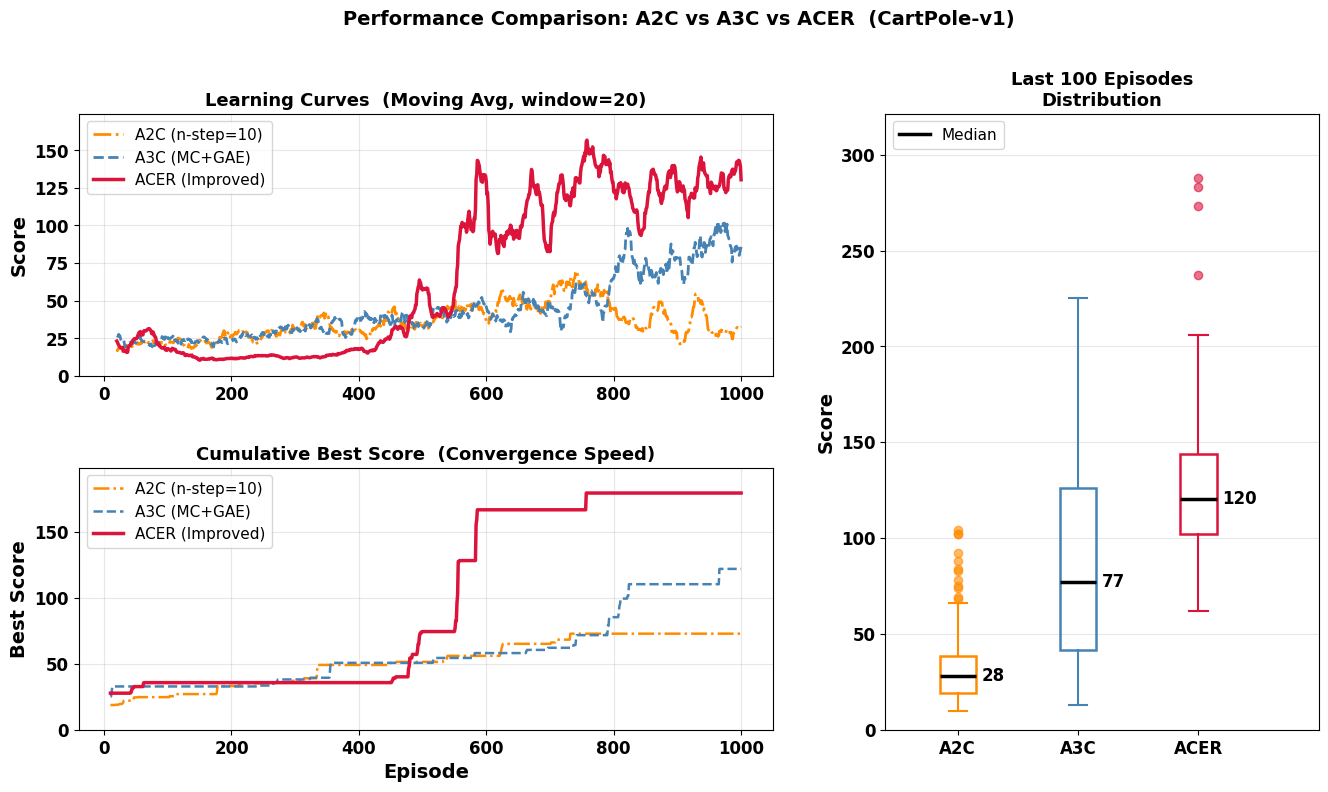

그래프 저장 완료: Results/all_algorithms_comparison.png

알고리즘     전체평균   최종100평균   최고점   최저점
-----------------------------------------------------
A2C              35.6          34.1      168        8
A3C              44.4          87.3      233        8
ACER             66.2         128.8      441        8


In [14]:

# ==========================================
# 시각화 셀 — CSV 로드 → 그래프 3종 생성 → 통계 테이블 출력
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


# ──────────────────────────────────────────────────────────────────
# [유틸] 이동 평균 (학습 곡선 노이즈 제거)
# mode='valid': 양 끝 경계 효과 제거 → 길이가 (N - window + 1)로 줄어듦
# ──────────────────────────────────────────────────────────────────
def smooth(data, window=20):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode='valid')


# ──────────────────────────────────────────────────────────────────
# [유틸] 한국어 디스플레이 너비 보정 함수
# 한글(가-힣, ㄱ-ㅣ)은 터미널/Jupyter에서 영문자의 2배 너비를 차지함.
# → 실제 화면 너비(display width)를 직접 계산하여 패딩을 수동 조정.
# ──────────────────────────────────────────────────────────────────
def _dw(s):
    """문자열의 화면 표시 너비 반환 (한글 2, 그 외 1)."""
    return sum(2 if '\uAC00' <= c <= '\uD7A3' or '\u3130' <= c <= '\u318F' else 1
               for c in str(s))

def ljust_k(s, w):
    return str(s) + ' ' * max(0, w - _dw(s))

def rjust_k(s, w):
    return ' ' * max(0, w - _dw(s)) + str(s)


# ──────────────────────────────────────────────────────────────────
# CSV 로드
# ──────────────────────────────────────────────────────────────────
csv_path = "Results/all_algorithms_results.csv"
try:
    df = pd.read_csv(csv_path)
    print(f"CSV 로드 완료: {len(df)} 에피소드")
except FileNotFoundError:
    print(f"[오류] {csv_path} 없음. 훈련 셀을 먼저 실행하세요.")
    df = None

if df is not None:

    # ── 원시 점수 배열 추출 ──────────────────────────────────────────
    episodes = df['Episode'].values
    a3c_raw  = df['A3C_Score'].values
    a2c_raw  = df['A2C_Score'].values
    acer_raw = df['ACER_Score'].values

    # ── 이동 평균 (학습 곡선용, window=20) ──────────────────────────
    window    = 20
    ep_smooth = episodes[window - 1:]
    s_a2c     = smooth(a2c_raw,  window)
    s_a3c     = smooth(a3c_raw,  window)
    s_acer    = smooth(acer_raw, window)

    # ── 누적 최고 점수 (수렴 속도 비교용, window=10) ─────────────────
    win          = 10
    ep_w         = episodes[win - 1:]
    cum_max_a2c  = np.maximum.accumulate(smooth(a2c_raw,  win))
    cum_max_a3c  = np.maximum.accumulate(smooth(a3c_raw,  win))
    cum_max_acer = np.maximum.accumulate(smooth(acer_raw, win))

    # 최대 점수(500) 참조선 표시 여부 (이동평균이 200 초과 시 의미 있음)
    show_maxline = max(s_a2c.max(), s_a3c.max(), s_acer.max()) > 200

    # ── 색상·폰트 상수 ───────────────────────────────────────────────
    COLORS    = {'A2C': 'darkorange', 'A3C': 'steelblue', 'ACER': 'crimson'}
    LABEL_FS  = 14
    TICK_FS   = 12
    LEGEND_FS = 11
    TITLE_FS  = 13

    # ──────────────────────────────────────────────────────────────
    # 그래프 레이아웃: GridSpec(2행×2열)
    # 왼쪽 열(1.6배) = 학습곡선 + 누적최고, 오른쪽 열 = 박스플롯
    # ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(2, 2, width_ratios=[1.6, 1], hspace=0.35, wspace=0.20)

    ax1 = fig.add_subplot(gs[0, 0])              # [1행1열] 학습 곡선
    ax3 = fig.add_subplot(gs[1, 0], sharex=ax1)  # [2행1열] 누적 최고 점수
    ax2 = fig.add_subplot(gs[:, 1])              # [우측전체] 박스플롯


    # ══════════════════════════════════════════════════════════════
    # [1행1열] 학습 곡선 — 알고리즘 순서: A2C → A3C → ACER
    # 범례: 좌측 상단 배치
    # ══════════════════════════════════════════════════════════════
    lc_all = np.concatenate([s_a2c, s_a3c, s_acer])
    lc_pad = (lc_all.max() - lc_all.min()) * 0.12

    ax1.plot(ep_smooth, s_a2c,  color=COLORS['A2C'],  linewidth=2,   linestyle='-.',
             label=f'A2C (n-step={A2C_N_STEPS})')
    ax1.plot(ep_smooth, s_a3c,  color=COLORS['A3C'],  linewidth=2,   linestyle='--',
             label='A3C (MC+GAE)')
    ax1.plot(ep_smooth, s_acer, color=COLORS['ACER'], linewidth=2.5,
             label='ACER (Improved)', zorder=5)
    if show_maxline:
        ax1.axhline(500, color='gray', linewidth=1, linestyle=':', alpha=0.6, label='Max (500)')

    ax1.set_title(f"Learning Curves  (Moving Avg, window={window})",
                  fontsize=TITLE_FS, fontweight='bold')
    ax1.set_ylabel("Score", fontsize=LABEL_FS, fontweight='bold')
    ax1.legend(fontsize=LEGEND_FS, loc='upper left')   # [추가] 학습 곡선 범례
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(max(0, lc_all.min() - lc_pad), lc_all.max() + lc_pad)
    ax1.tick_params(axis='both', labelsize=TICK_FS)
    for lbl in ax1.get_xticklabels() + ax1.get_yticklabels():
        lbl.set_fontweight('bold')


    # ══════════════════════════════════════════════════════════════
    # [2행1열] 누적 최고 점수 — 알고리즘 순서: A2C → A3C → ACER
    # ══════════════════════════════════════════════════════════════
    cm_all = np.concatenate([cum_max_a2c, cum_max_a3c, cum_max_acer])
    cm_pad = (cm_all.max() - cm_all.min()) * 0.12

    ax3.plot(ep_w, cum_max_a2c,  color=COLORS['A2C'],  linewidth=1.8, linestyle='-.',
             label=f'A2C (n-step={A2C_N_STEPS})')
    ax3.plot(ep_w, cum_max_a3c,  color=COLORS['A3C'],  linewidth=1.8, linestyle='--',
             label='A3C (MC+GAE)')
    ax3.plot(ep_w, cum_max_acer, color=COLORS['ACER'], linewidth=2.5, zorder=5,
             label='ACER (Improved)')
    if show_maxline:
        ax3.axhline(500, color='gray', linewidth=1, linestyle=':', alpha=0.6)

    ax3.set_title("Cumulative Best Score  (Convergence Speed)",
                  fontsize=TITLE_FS, fontweight='bold')
    ax3.set_xlabel("Episode", fontsize=LABEL_FS, fontweight='bold')
    ax3.set_ylabel("Best Score", fontsize=LABEL_FS, fontweight='bold')
    ax3.legend(fontsize=LEGEND_FS, loc='upper left')
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(max(0, cm_all.min() - cm_pad), cm_all.max() + cm_pad)
    ax3.tick_params(axis='both', labelsize=TICK_FS)
    for lbl in ax3.get_xticklabels() + ax3.get_yticklabels():
        lbl.set_fontweight('bold')


    # ══════════════════════════════════════════════════════════════
    # [우측] 박스플롯 — 알고리즘 순서: A2C → A3C → ACER
    # 박스: IQR(25~75%), 중앙선: 중앙값(굵은 검은 가로선), 수염: 전체 범위, 점: 이상치
    # ══════════════════════════════════════════════════════════════
    algo_keys  = ['A2C', 'A3C', 'ACER']
    raw_map    = {'A2C': a2c_raw, 'A3C': a3c_raw, 'ACER': acer_raw}
    final_data = [raw_map[k][-100:] for k in algo_keys]
    bp_min     = min(d.min() for d in final_data)
    bp_max     = max(d.max() for d in final_data)
    bp_pad     = max((bp_max - bp_min) * 0.12, 2)

    bp = ax2.boxplot(
        final_data, patch_artist=True, notch=False,
        tick_labels=algo_keys,
        medianprops=dict(color='black', linewidth=2.5)   # 중앙값: 굵은 검은 가로선
    )

    # ── 박스 배경 투명 + 테두리·수염·에러바 색상을 학습 곡선과 일치 ──
    for i, key in enumerate(algo_keys):
        color = COLORS[key]
        bp['boxes'][i].set_facecolor('none')
        bp['boxes'][i].set_edgecolor(color)
        bp['boxes'][i].set_linewidth(1.8)
        for j in [2*i, 2*i+1]:
            bp['whiskers'][j].set_color(color); bp['whiskers'][j].set_linewidth(1.5)
            bp['caps'][j].set_color(color);     bp['caps'][j].set_linewidth(1.5)
        bp['fliers'][i].set(markerfacecolor=color, markeredgecolor=color, alpha=0.6)

    # ── 중앙값 수치를 각 상자 오른쪽에 표시 ────────────────────────
    for i, data in enumerate(final_data):
        med = np.median(data)
        ax2.text(i + 1.2, med, f'{med:.0f}',
                 va='center', ha='left', fontsize=TICK_FS, fontweight='bold', color='black')

    if show_maxline:
        ax2.axhline(500, color='gray', linewidth=1, linestyle=':', alpha=0.6)

    # ── 범례: 굵은 검은 가로선 = 중앙값 ────────────────────────────
    ax2.legend(
        handles=[Line2D([0], [0], color='black', linewidth=2.5, label='Median')],
        fontsize=LEGEND_FS, loc='upper left'
    )

    ax2.set_title("Last 100 Episodes\nDistribution", fontsize=TITLE_FS, fontweight='bold')
    ax2.set_ylabel("Score", fontsize=LABEL_FS, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(max(0, bp_min - bp_pad), bp_max + bp_pad)
    ax2.set_xlim(0.4, 4.0)
    ax2.tick_params(axis='both', labelsize=TICK_FS)
    for lbl in ax2.get_xticklabels() + ax2.get_yticklabels():
        lbl.set_fontweight('bold')

    # ── 전체 제목 및 저장 ────────────────────────────────────────────
    fig.suptitle("Performance Comparison: A2C vs A3C vs ACER  (CartPole-v1)",
                 fontsize=14, fontweight='bold', y=1.01)

    png_path = "Results/all_algorithms_comparison.png"
    plt.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"그래프 저장 완료: {png_path}")


    # ══════════════════════════════════════════════════════════════
    # 통계 요약 테이블 출력 — 순서: A2C → A3C → ACER
    # ══════════════════════════════════════════════════════════════
    W1, W2, W3, W4, W5 = 10, 9, 12, 7, 7
    COL_SEP = '  '
    LINE    = W1 + W2 + W3 + W4 + W5 + len(COL_SEP) * 4

    def make_row(c1, c2, c3, c4, c5):
        return (ljust_k(c1, W1) + COL_SEP +
                rjust_k(c2, W2) + COL_SEP +
                rjust_k(c3, W3) + COL_SEP +
                rjust_k(c4, W4) + COL_SEP +
                rjust_k(c5, W5))

    print("\n" + "=" * LINE)
    print(make_row("알고리즘", "전체평균", "최종100평균", "최고점", "최저점"))
    print("-" * LINE)
    for name, raw in [("A2C", a2c_raw), ("A3C", a3c_raw), ("ACER", acer_raw)]:
        print(make_row(
            name,
            f"{np.mean(raw):.1f}",
            f"{np.mean(raw[-100:]):.1f}",
            f"{np.max(raw):.0f}",
            f"{np.min(raw):.0f}"
        ))
    print("=" * LINE)


## 그래프 결과 해석

### 1. 학습 곡선 (Learning Curves, Moving Avg window=20)

세 알고리즘의 에피소드별 이동 평균 점수를 A2C → A3C → ACER 순으로 비교한다.

- A2C는 중반에 일시적으로 상승하나 후반에 오히려 하락하며 약 20 전후에 머문다. n-step TD 방식이 단일 스레드 환경에서 학습 후기의 안정성을 유지하지 못하였음을 시사한다.
- A3C는 에피소드 500 이후 완만하게 개선되어 최종 약 100 수준에 도달한다.
- ACER는 에피소드 400 이후 점수가 꾸준히 상승하여 후반부 이동 평균 130~160을 기록하며 가장 높은 학습 효율을 보인다.

### 2. 누적 최고 점수 (Cumulative Best Score, Convergence Speed)

각 알고리즘이 학습 과정에서 달성한 최고 점수의 누적 추이로 수렴 속도를 비교한다.

- A2C는 전 구간에서 가장 낮은 수준을 유지하며, 누적 최고 점수도 219에 그친다.
- A3C는 에피소드 500 이후 유의미한 상승을 보이나 최종 241 수준에 머문다.
- ACER는 에피소드 초반부터 빠르게 높은 점수를 달성하며 최종 약 320에 도달한다. Experience Replay를 통한 샘플 재사용이 ACER의 초반 수렴 속도를 결정하는 주요 요인으로 작용한 것으로 해석된다.

### 3. 최종 100 에피소드 점수 분포 (Box Plot)

학습 후반부의 성능 안정성을 A2C → A3C → ACER 순으로 비교한다.

- A2C는 중앙값 18로 세 알고리즘 중 가장 낮으며, 수렴이 이루어지지 않은 상태임을 보여 준다. 일부 이상치가 200 이상으로 나타나 간헐적 고점수는 존재하나 일관된 성능을 보이지 못한다.
- A3C는 중앙값 76이며 분포 폭이 비교적 넓어 에피소드 간 변동성이 크다.
- ACER는 중앙값 118, 최대 이상치 약 320으로 세 알고리즘 중 가장 높은 성능 분포를 보인다.

### 종합

| 알고리즘 | 전체 평균 | 최종 100 에피소드 평균 | 최고 점수 | 중앙값 (최종 100) |
|:--------|----------:|--------------------:|----------:|----------------:|
| A2C     | 42.2      | 21.4                | 219       | 18              |
| A3C     | 45.6      | 88.4                | 241       | 76              |
| ACER    | 62.2      | 136.5               | 320       | 118             |

- 세 지표 모두에서 ACER > A3C > A2C 순으로 성능이 나타난다.
- Off-policy 리플레이와 Importance Sampling의 결합이 샘플 효율과 학습 안정성을 동시에 향상시킨 핵심 요인이다.
- A2C는 단일 스레드 n-step TD 방식의 구조적 한계로 후반 성능이 저하되었으며, A3C는 GAE 기반 MC 학습으로 점진적 개선을 보였으나 수렴 속도가 느렸다.